# Predictions with a statistical model

In machine learning, we have a **population** of $N$ instances $(x_i,y_i)_{i=1}^N$ but we first consider the statistical setting (called decision theory) where we know the **distribution** of $(X,Y)$. The question is then: given a sample $x$ from this distribution, what is the best prediction for the associated $y$?
We restrict ourselves to binary prediction, i.e. the target $Y\in \{0,1\}$.

## Optimal prediction

**Modeling knowledge** as a probability distribution with a statistical model $p(x,y)$.

Prior for $Y$: $p(y)$ in our case: $p_0= \mathbb{P}(Y=0)$ and $p_1=1-p_0$.

Generative model: $p(x|y)$. So that $p(x,y) = p(x|y)p(y)$. [Bayes rule](https://en.wikipedia.org/wiki/Bayes%27_theorem)

We denote by $\hat{y}(X)$ the predictor for input $X$. For classification, we ask for $\hat{y}:\mathbb{R}\to \{0,1\}$.

The confusion matrix is given by:

|        | Y=0            | Y=1            |
|--------|----------------|----------------|
| ŷ=0    | True negative  | False negative |
| ŷ=1    | False positive | True positive  |

A few definitions:

- **true positive rate (TPR)**: $\mathbb{P}(\hat{y}=1|Y=1)$ also called sensitivity or recall.
- **false negative rate (FNR)**: $\mathbb{P}(\hat{y}=0|Y=1)=1-\text{TPR}$ also known as type II error.
- **false positive rate (FPR)**: $\mathbb{P}(\hat{y}=1|Y=0)$ also known as type I error.
- **true negative rate (TNR)**: $\mathbb{P}(\hat{y}=0|Y=0)=1-\text{FPR}$.
- **precision**: $\mathbb{P}(Y=1|\hat{y}=1) = \frac{p_1 \text{TPR}}{p_1\text{TPR} + p_0\text{FPR}}$.
- **$F_1$ score** is the harmonic mean of precision and recall.

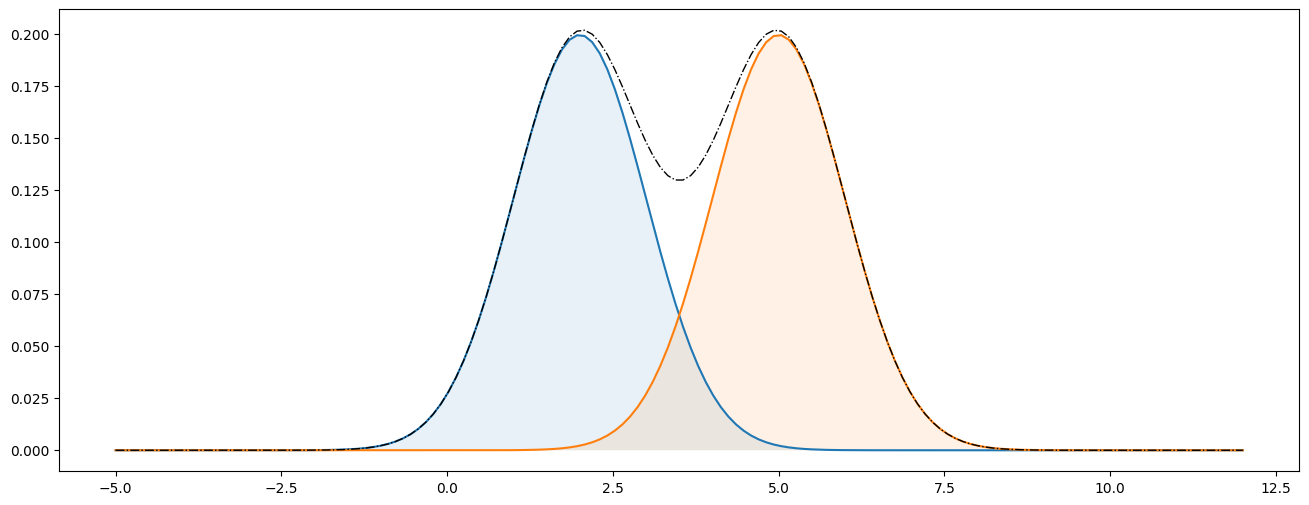

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats

p = 0.5
ps = [p, 1-p]
mus = [2, 5]
generative_m = np.array([stats.norm(mus[0], 1), stats.norm(mus[1], 1)])

# plot the latent distributions
x = np.linspace(-5, 12, 150)
plt.figure(figsize=(16, 6))
plt.plot(x, ps[0]*generative_m[0].pdf(x))
plt.plot(x, ps[1]*generative_m[1].pdf(x))
plt.plot(x, ps[0]*generative_m[0].pdf(x) + ps[1]*generative_m[1].pdf(x), lw=1, ls='-.', color='black')
plt.fill_betweenx(ps[0]*generative_m[0].pdf(x), x, alpha=0.1)
plt.fill_betweenx(ps[1]*generative_m[1].pdf(x), x, alpha=0.1)

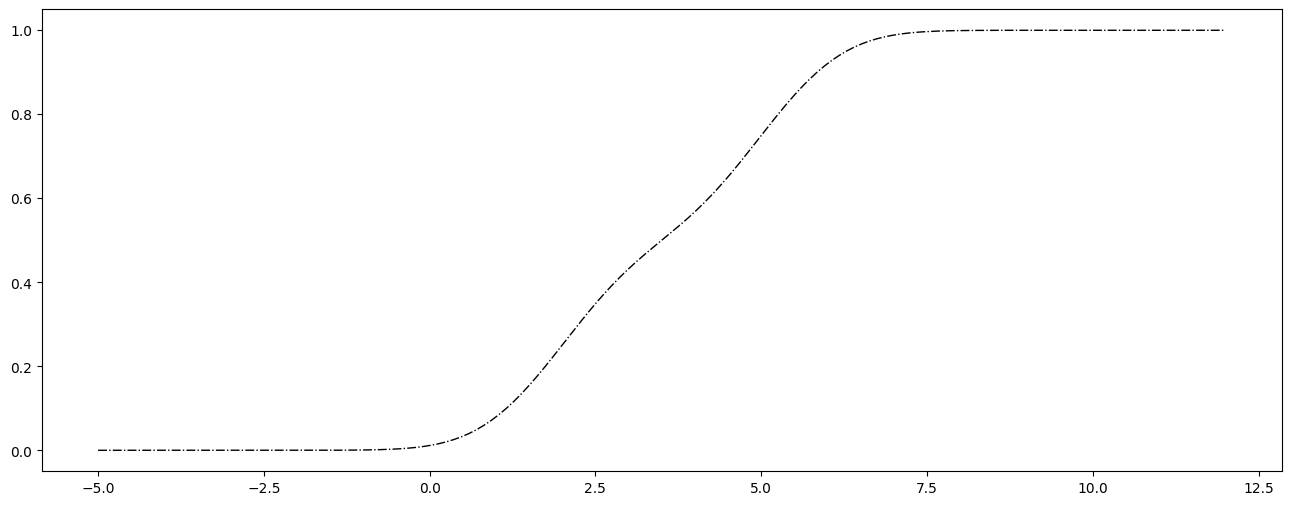

In [3]:
plt.figure(figsize=(16, 6))
plt.plot(x, ps[0]*generative_m[0].cdf(x) + ps[1]*generative_m[1].cdf(x), lw=1, ls='-.', color='black')

- **True Positive Rate** $=\mathbb{P}(\hat{Y}(X)=1|Y=1)$
- **False Positive Rate** $=\mathbb{P}(\hat{Y}(X)=1|Y=0)$

In [4]:
def compute_TPR_FPR(t, generative_m = generative_m):
    pass
def compute_error(t, generative_m = generative_m, ps=ps):
    pass
def compute_Precision_Recall(t, generative_m = generative_m, ps=ps):
    pass

In [6]:
ts = np.linspace(-10, 10, 1000) #thresholds
###

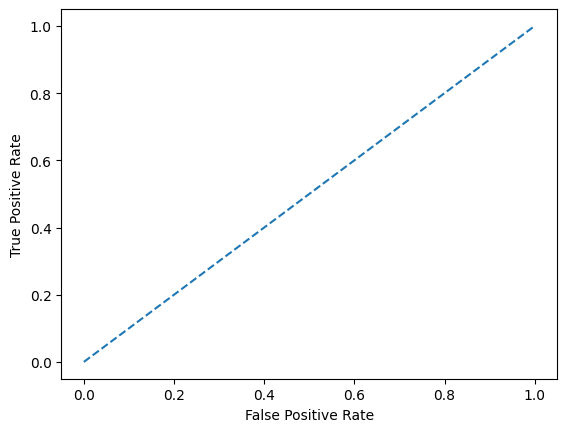

In [5]:
# Plot ROC
plt.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate');

In [7]:
#plot accuracy = 1 - error

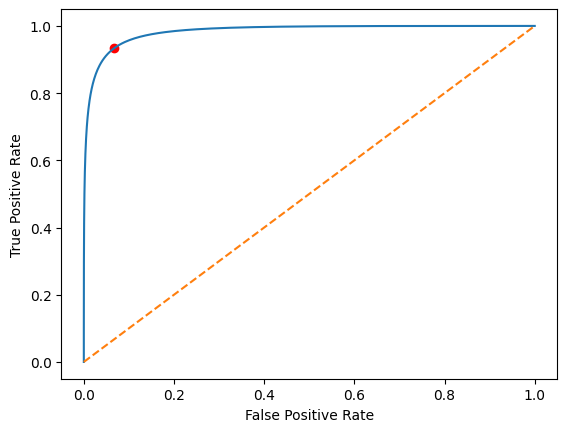

In [45]:
plt.plot([r[1] for r in ROC], [r[0] for r in ROC])
plt.scatter(compute_TPR_FPR(3.5)[1], compute_TPR_FPR(3.5)[0], color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), linestyle='--');

In [46]:
p_unbalanced = 0.90
ps_unbalanced = [p_unbalanced, 1-p_unbalanced]
accuracy_unbalanced = [1-compute_error(t, ps=ps_unbalanced) for t in ts]

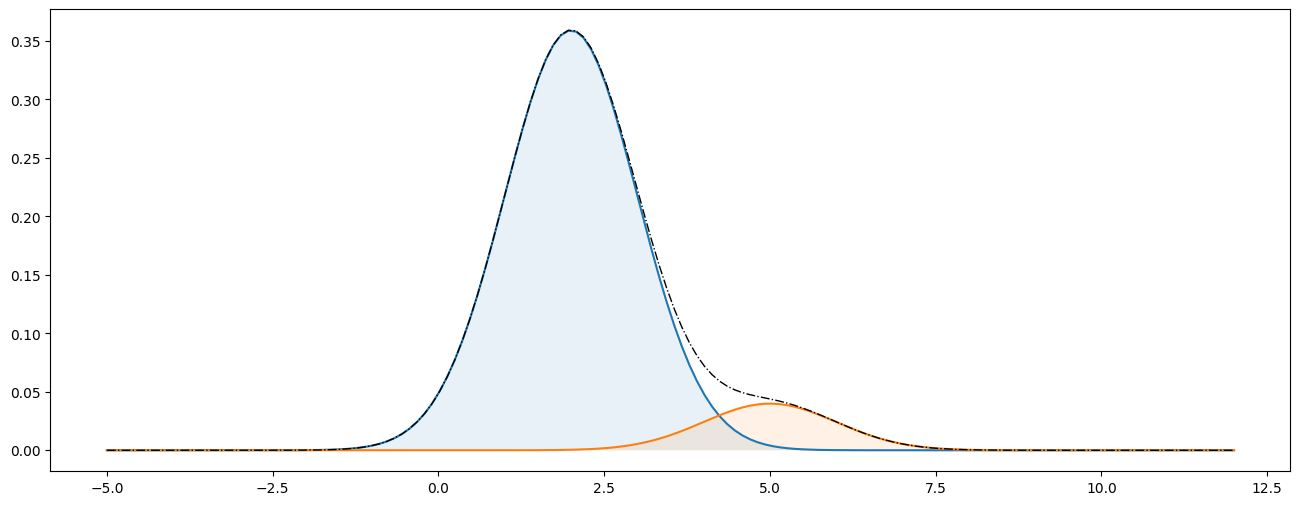

In [47]:
# plot the latent distributions
x = np.linspace(-5, 12, 150)
plt.figure(figsize=(16, 6))
plt.plot(x, ps_unbalanced[0]*generative_m[0].pdf(x))
plt.plot(x, ps_unbalanced[1]*generative_m[1].pdf(x))
plt.plot(x, ps_unbalanced[0]*generative_m[0].pdf(x) + ps_unbalanced[1]*generative_m[1].pdf(x), lw=1, ls='-.', color='black')
plt.fill_betweenx(ps_unbalanced[0]*generative_m[0].pdf(x), x, alpha=0.1)
plt.fill_betweenx(ps_unbalanced[1]*generative_m[1].pdf(x), x, alpha=0.1)

In [ ]:
#compare ROC curves

In [8]:
#compare accuracies

- **Recall = True Positive Rate**
- **Precision** $=\mathbb{P}(Y=1|\hat{Y}(X)=1)$

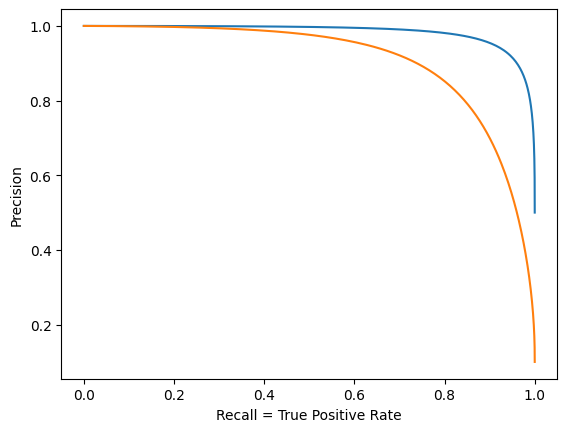

In [49]:
Prec_Rec = [compute_Precision_Recall(t) for t in ts]
Prec_Rec_unbalanced = [compute_Precision_Recall(t, ps=ps_unbalanced) for t in ts]
plt.plot([r[1] for r in Prec_Rec], [r[0] for r in Prec_Rec])
plt.plot([r[1] for r in Prec_Rec_unbalanced], [r[0] for r in Prec_Rec_unbalanced])
plt.ylabel('Precision')
plt.xlabel('Recall = True Positive Rate');